# An End to End Project on Exploratory Data Analysis for a Financial Dataset

### Importing necessary libraries 

In [139]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
%matplotlib inline

### import dataset | Reading Dataset


In [140]:
df_dataset = pd.read_csv(r"C:\Users\benke\Downloads\archive (18)\Financials.csv")
df_dataset.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,6,June,2014


### Data Investigation

In [141]:
df_dataset.shape 

(700, 16)

In [142]:
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Segment                700 non-null    object
 1   Country                700 non-null    object
 2    Product               700 non-null    object
 3    Discount Band         700 non-null    object
 4    Units Sold            700 non-null    object
 5    Manufacturing Price   700 non-null    object
 6    Sale Price            700 non-null    object
 7    Gross Sales           700 non-null    object
 8    Discounts             700 non-null    object
 9     Sales                700 non-null    object
 10   COGS                  700 non-null    object
 11   Profit                700 non-null    object
 12  Date                   700 non-null    object
 13  Month Number           700 non-null    int64 
 14   Month Name            700 non-null    object
 15  Year                   

In [143]:
df_dataset.isnull().sum()

Segment                  0
Country                  0
 Product                 0
 Discount Band           0
 Units Sold              0
 Manufacturing Price     0
 Sale Price              0
 Gross Sales             0
 Discounts               0
  Sales                  0
 COGS                    0
 Profit                  0
Date                     0
Month Number             0
 Month Name              0
Year                     0
dtype: int64

In [144]:
import missingno as msno

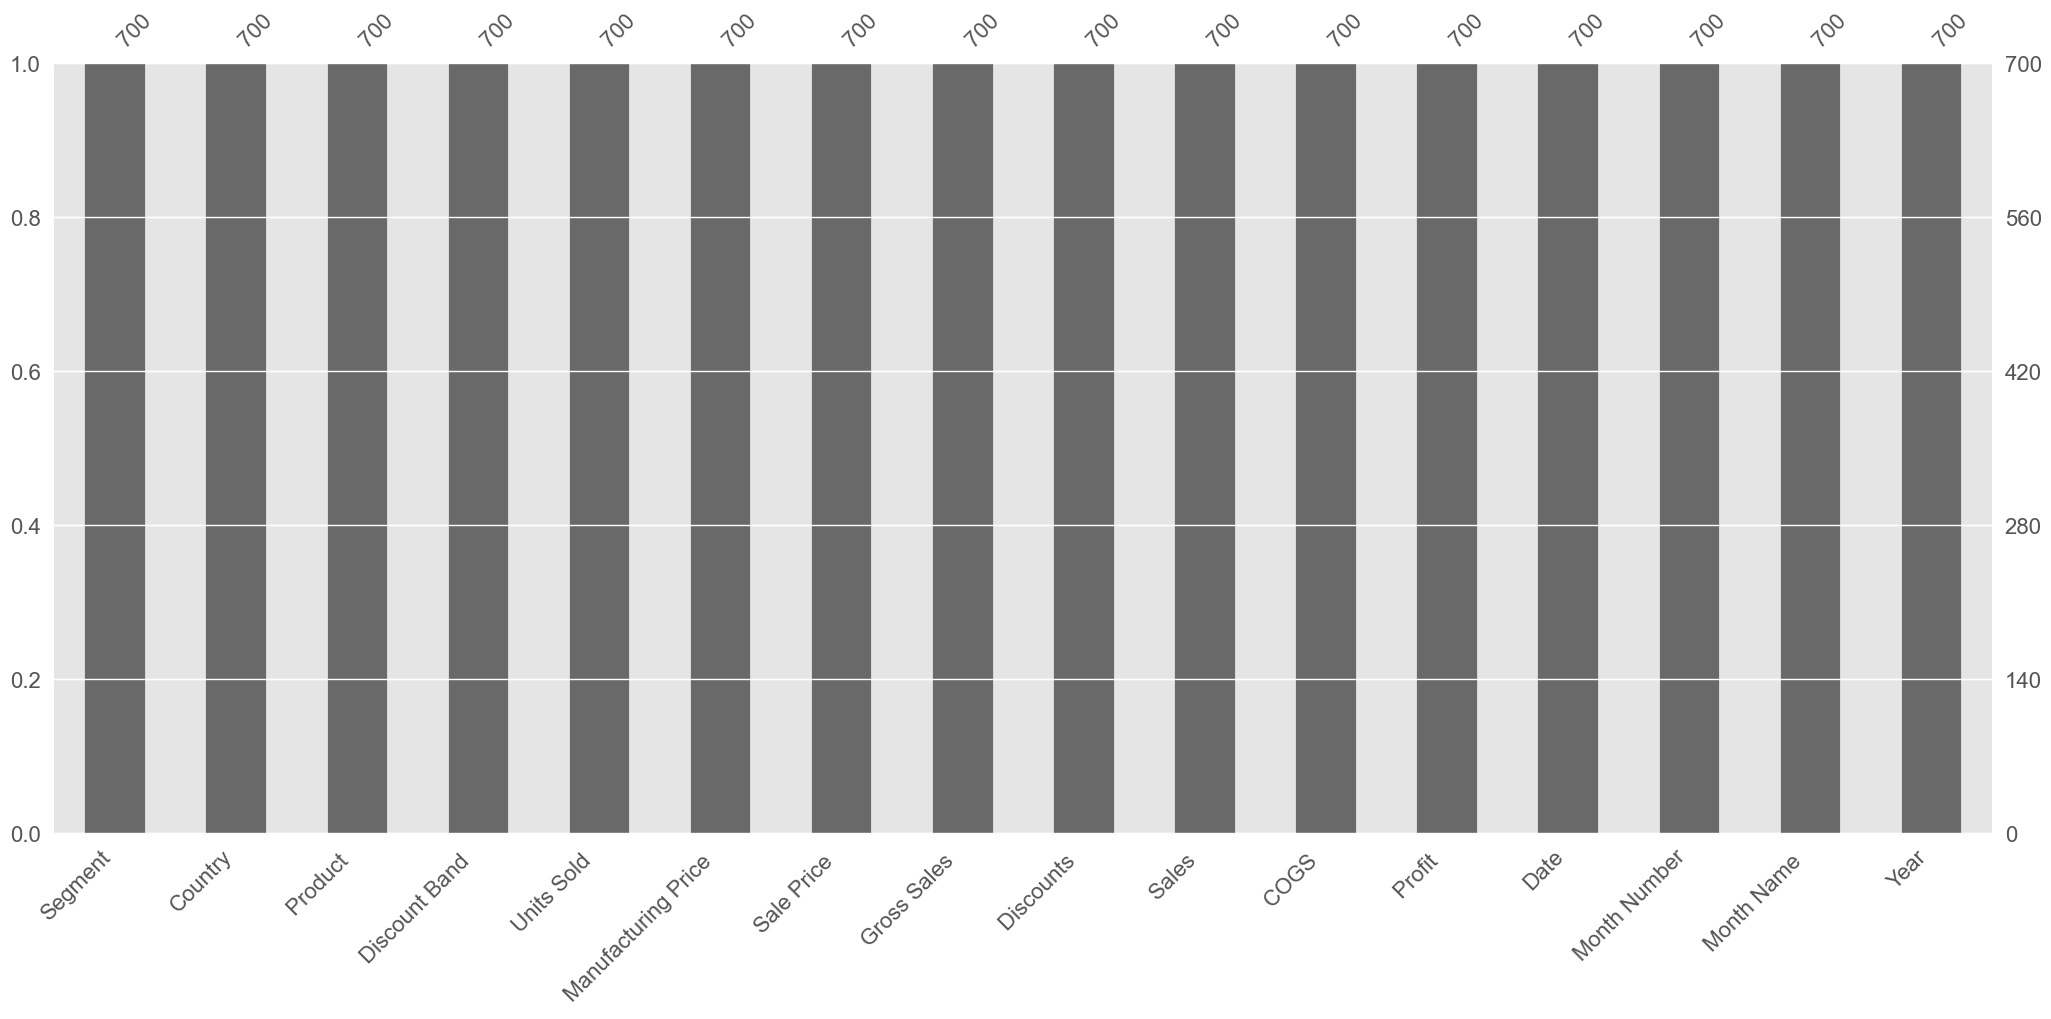

In [145]:
msno.bar(df_dataset)
plt.show()

In [146]:
df_dataset.duplicated().sum()

0

In [147]:
df_dataset.describe()

,Month Number,Year
count,700.000000,700.000000
mean,7.900000,2013.750000
std,3.377321,0.433322
min,1.000000,2013.000000
25%,5.750000,2013.750000
50%,9.000000,2014.000000
75%,10.250000,2014.000000
max,12.000000,2014.000000


## Data Wrangling | Preprocessing

In [148]:
# dropping Month Number and Year Columns from DataFrame
df_dataset.drop(columns=['Month Number', 'Year'], inplace = True)

In [149]:
# checking results after dropping columns
df_dataset.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Name
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,January
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,January
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,June
3,Midmarket,Germany,Carretera,None,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,June
4,Midmarket,Mexico,Carretera,None,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,June


In [150]:
# confirming datatypes
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Segment                700 non-null    object
 1   Country                700 non-null    object
 2    Product               700 non-null    object
 3    Discount Band         700 non-null    object
 4    Units Sold            700 non-null    object
 5    Manufacturing Price   700 non-null    object
 6    Sale Price            700 non-null    object
 7    Gross Sales           700 non-null    object
 8    Discounts             700 non-null    object
 9     Sales                700 non-null    object
 10   COGS                  700 non-null    object
 11   Profit                700 non-null    object
 12  Date                   700 non-null    object
 13   Month Name            700 non-null    object
dtypes: object(14)
memory usage: 76.7+ KB


In [151]:
# showing columns to check for whitespaces
print(df_dataset.columns)

Index(['Segment', 'Country', ' Product ', ' Discount Band ', ' Units Sold ',
       ' Manufacturing Price ', ' Sale Price ', ' Gross Sales ', ' Discounts ',
       '  Sales ', ' COGS ', ' Profit ', 'Date', ' Month Name '],
      dtype='object')


In [152]:
# striping columns off whitespaces
#Note: When you do df = df.columns.str.strip(), you are modifying the DF not the columns
# The above will change the DF to an index which will mess up the whole DF. We work with columns like below

df_dataset.columns = df_dataset.columns.str.strip()

In [153]:
# checking result
print(df_dataset.columns)

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month Name'],
      dtype='object')


In [154]:
# converting columns to appropriate datatypes
convert_columns = ['Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit']

In [155]:
# Looping through each column name in the Number_Columns list
for col in convert_columns:
    # Removing non-numeric characters (except periods) from the column using regex
    df_dataset[col] = df_dataset[col].str.replace('[^0-9.]', '', regex=True)
    # Replacing empty strings with NaN values
    df_dataset[col] = df_dataset[col].replace('', np.nan)
    # Converting the column to float type for numeric calculations
    df_dataset[col] = df_dataset[col].astype(float)

In [156]:
# checking result
df_dataset

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Name
0,Government,Canada,Carretera,None,1618.5,3.0,20.0,32370.0,NaN,32370.00,16185.0,16185.00,01/01/2014,January
1,Government,Germany,Carretera,None,1321.0,3.0,20.0,26420.0,NaN,26420.00,13210.0,13210.00,01/01/2014,January
2,Midmarket,France,Carretera,None,2178.0,3.0,15.0,32670.0,NaN,32670.00,21780.0,10890.00,01/06/2014,June
3,Midmarket,Germany,Carretera,None,888.0,3.0,15.0,13320.0,NaN,13320.00,8880.0,4440.00,01/06/2014,June
4,Midmarket,Mexico,Carretera,None,2470.0,3.0,15.0,37050.0,NaN,37050.00,24700.0,12350.00,01/06/2014,June
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Small Business,France,Amarilla,High,2475.0,260.0,300.0,742500.0,111375.00,631125.00,618750.0,12375.00,01/03/2014,March
696,Small Business,Mexico,Amarilla,High,546.0,260.0,300.0,163800.0,24570.00,139230.00,136500.0,2730.00,01/10/2014,October
697,Government,Mexico,Montana,High,1368.0,5.0,7.0,9576.0,1436.40,8139.60,6840.0,1299.60,01/02/2014,February
698,Government,Canada,Paseo,High,723.0,10.0,7.0,5061.0,759.15,4301.85,3615.0,686.85,01/04/2014,April


In [157]:
# checking for missing values
df_dataset.isnull().sum()

Segment                 0
Country                 0
Product                 0
Discount Band           0
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts              53
Sales                   0
COGS                    0
Profit                  5
Date                    0
Month Name              0
dtype: int64

In [158]:
# handling missing values using bfill
df_dataset['Discounts'] = df_dataset['Discounts'].fillna(method ='bfill')

In [159]:
# checking result
df_dataset

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Name
0,Government,Canada,Carretera,None,1618.5,3.0,20.0,32370.0,276.15,32370.00,16185.0,16185.00,01/01/2014,January
1,Government,Germany,Carretera,None,1321.0,3.0,20.0,26420.0,276.15,26420.00,13210.0,13210.00,01/01/2014,January
2,Midmarket,France,Carretera,None,2178.0,3.0,15.0,32670.0,276.15,32670.00,21780.0,10890.00,01/06/2014,June
3,Midmarket,Germany,Carretera,None,888.0,3.0,15.0,13320.0,276.15,13320.00,8880.0,4440.00,01/06/2014,June
4,Midmarket,Mexico,Carretera,None,2470.0,3.0,15.0,37050.0,276.15,37050.00,24700.0,12350.00,01/06/2014,June
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Small Business,France,Amarilla,High,2475.0,260.0,300.0,742500.0,111375.00,631125.00,618750.0,12375.00,01/03/2014,March
696,Small Business,Mexico,Amarilla,High,546.0,260.0,300.0,163800.0,24570.00,139230.00,136500.0,2730.00,01/10/2014,October
697,Government,Mexico,Montana,High,1368.0,5.0,7.0,9576.0,1436.40,8139.60,6840.0,1299.60,01/02/2014,February
698,Government,Canada,Paseo,High,723.0,10.0,7.0,5061.0,759.15,4301.85,3615.0,686.85,01/04/2014,April


In [160]:
# checking for null values to confirm they were handled
df_dataset.isnull().sum()

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 5
Date                   0
Month Name             0
dtype: int64

In [161]:
#replacing missing values in profit
df_dataset['Profit'] = df_dataset['Profit'].fillna(method='bfill')

In [162]:
df_dataset.isnull().sum()

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month Name             0
dtype: int64

In [163]:
df_dataset

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Name
0,Government,Canada,Carretera,None,1618.5,3.0,20.0,32370.0,276.15,32370.00,16185.0,16185.00,01/01/2014,January
1,Government,Germany,Carretera,None,1321.0,3.0,20.0,26420.0,276.15,26420.00,13210.0,13210.00,01/01/2014,January
2,Midmarket,France,Carretera,None,2178.0,3.0,15.0,32670.0,276.15,32670.00,21780.0,10890.00,01/06/2014,June
3,Midmarket,Germany,Carretera,None,888.0,3.0,15.0,13320.0,276.15,13320.00,8880.0,4440.00,01/06/2014,June
4,Midmarket,Mexico,Carretera,None,2470.0,3.0,15.0,37050.0,276.15,37050.00,24700.0,12350.00,01/06/2014,June
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,Small Business,France,Amarilla,High,2475.0,260.0,300.0,742500.0,111375.00,631125.00,618750.0,12375.00,01/03/2014,March
696,Small Business,Mexico,Amarilla,High,546.0,260.0,300.0,163800.0,24570.00,139230.00,136500.0,2730.00,01/10/2014,October
697,Government,Mexico,Montana,High,1368.0,5.0,7.0,9576.0,1436.40,8139.60,6840.0,1299.60,01/02/2014,February
698,Government,Canada,Paseo,High,723.0,10.0,7.0,5061.0,759.15,4301.85,3615.0,686.85,01/04/2014,April


In [164]:
df_copy = df_dataset.copy()

## Handling Outliers

In [165]:
# extracting numerical columns
num_col = df_dataset.select_dtypes(include = ['int', 'float'])

In [166]:
#extracting categorical columns
cat_col = df_dataset.select_dtypes(include = ['object'])

In [167]:
cat_col

,Segment,Country,Product,Discount Band,Date,Month Name
0,Government,Canada,Carretera,None,01/01/2014,January
1,Government,Germany,Carretera,None,01/01/2014,January
2,Midmarket,France,Carretera,None,01/06/2014,June
3,Midmarket,Germany,Carretera,None,01/06/2014,June
4,Midmarket,Mexico,Carretera,None,01/06/2014,June
...,...,...,...,...,...,...
695,Small Business,France,Amarilla,High,01/03/2014,March
696,Small Business,Mexico,Amarilla,High,01/10/2014,October
697,Government,Mexico,Montana,High,01/02/2014,February
698,Government,Canada,Paseo,High,01/04/2014,April


In [168]:
# changing Date datatype from cat to datetime
cat_col['Date'] = pd.to_datetime(cat_col['Date'])

In [169]:
cat_col.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Segment        700 non-null    object        
 1   Country        700 non-null    object        
 2   Product        700 non-null    object        
 3   Discount Band  700 non-null    object        
 4   Date           700 non-null    datetime64[ns]
 5   Month Name     700 non-null    object        
dtypes: datetime64[ns](1), object(5)
memory usage: 32.9+ KB


In [170]:
# drop Date from cat_col

In [171]:
cat_col = cat_col.drop(['Date'], axis = 1)

In [172]:
cat_col

,Segment,Country,Product,Discount Band,Month Name
0,Government,Canada,Carretera,None,January
1,Government,Germany,Carretera,None,January
2,Midmarket,France,Carretera,None,June
3,Midmarket,Germany,Carretera,None,June
4,Midmarket,Mexico,Carretera,None,June
...,...,...,...,...,...
695,Small Business,France,Amarilla,High,March
696,Small Business,Mexico,Amarilla,High,October
697,Government,Mexico,Montana,High,February
698,Government,Canada,Paseo,High,April


In [173]:
num_col

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit
0,1618.5,3.0,20.0,32370.0,276.15,32370.00,16185.0,16185.00
1,1321.0,3.0,20.0,26420.0,276.15,26420.00,13210.0,13210.00
2,2178.0,3.0,15.0,32670.0,276.15,32670.00,21780.0,10890.00
3,888.0,3.0,15.0,13320.0,276.15,13320.00,8880.0,4440.00
4,2470.0,3.0,15.0,37050.0,276.15,37050.00,24700.0,12350.00
...,...,...,...,...,...,...,...,...
695,2475.0,260.0,300.0,742500.0,111375.00,631125.00,618750.0,12375.00
696,546.0,260.0,300.0,163800.0,24570.00,139230.00,136500.0,2730.00
697,1368.0,5.0,7.0,9576.0,1436.40,8139.60,6840.0,1299.60
698,723.0,10.0,7.0,5061.0,759.15,4301.85,3615.0,686.85


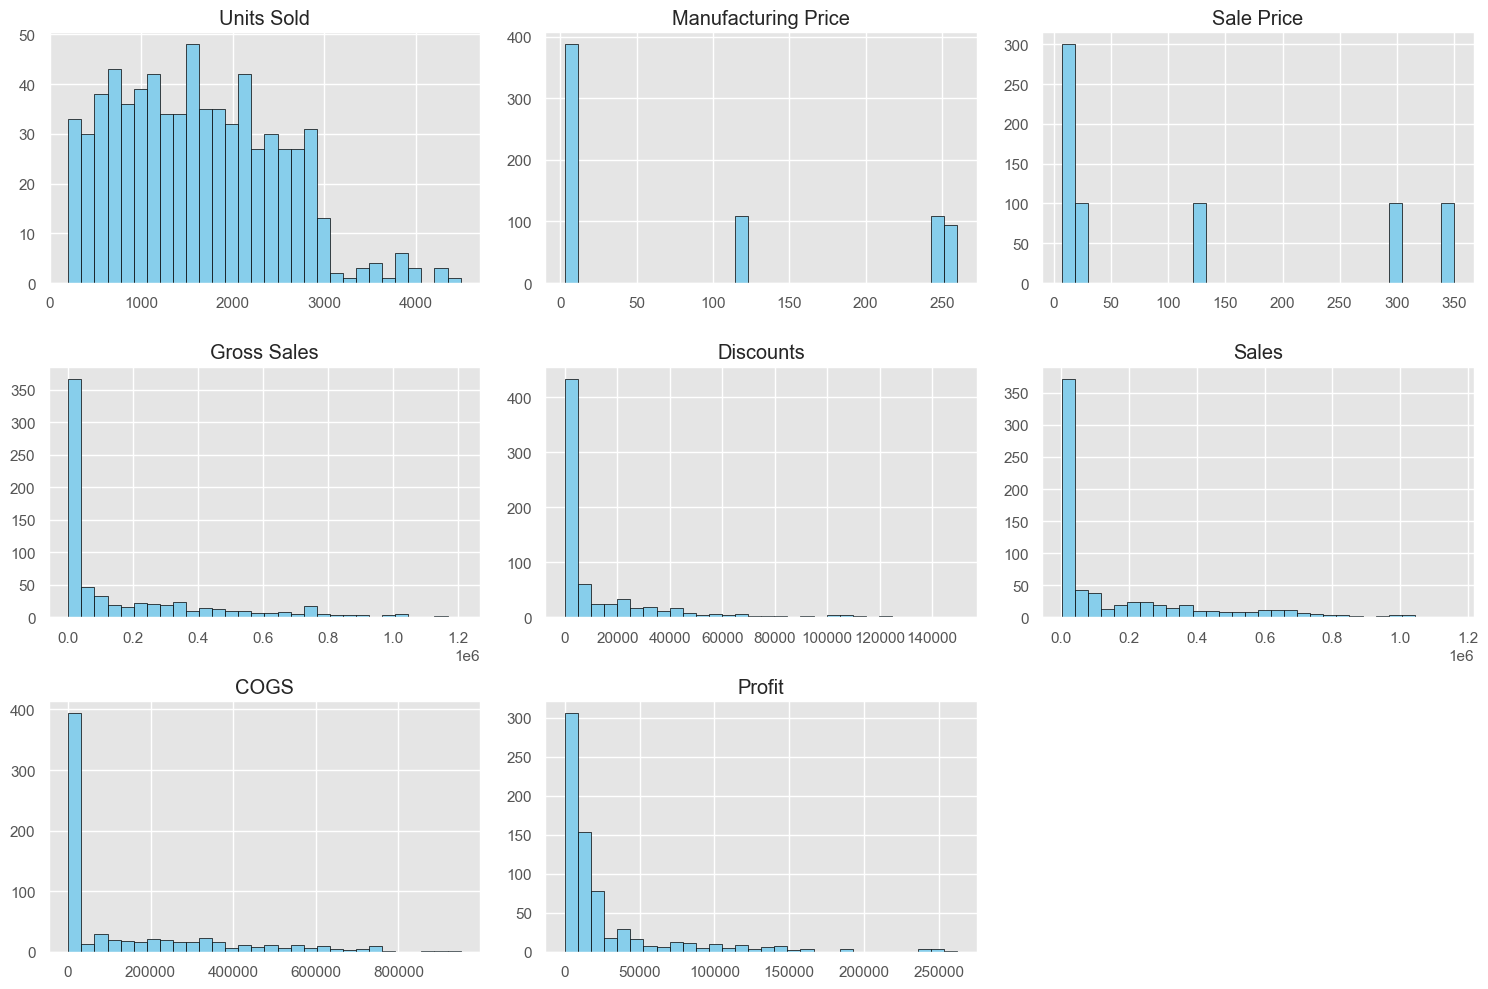

In [174]:
# Plot histograms for each numerical column
num_col.hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')

# Show the plots
plt.tight_layout()  # Adjusts subplot parameters to give specified padding
plt.show()


In [175]:
# Calculate the number of outliers for each numerical variable. We are using IQR to identify outliers
outliers_count = ((num_col < num_col.quantile(0.25) - 1.5 * (num_col.quantile(0.75) - num_col.quantile(0.25))) |
                  (num_col > num_col.quantile(0.75) + 1.5 * (num_col.quantile(0.75) - num_col.quantile(0.25))))
outliers_count = outliers_count.sum()

# Display the number of outliers in a table
print(outliers_count)

Units Sold              4
Manufacturing Price     0
Sale Price              0
Gross Sales            55
Discounts              75
Sales                  53
COGS                   36
Profit                 96
dtype: int64


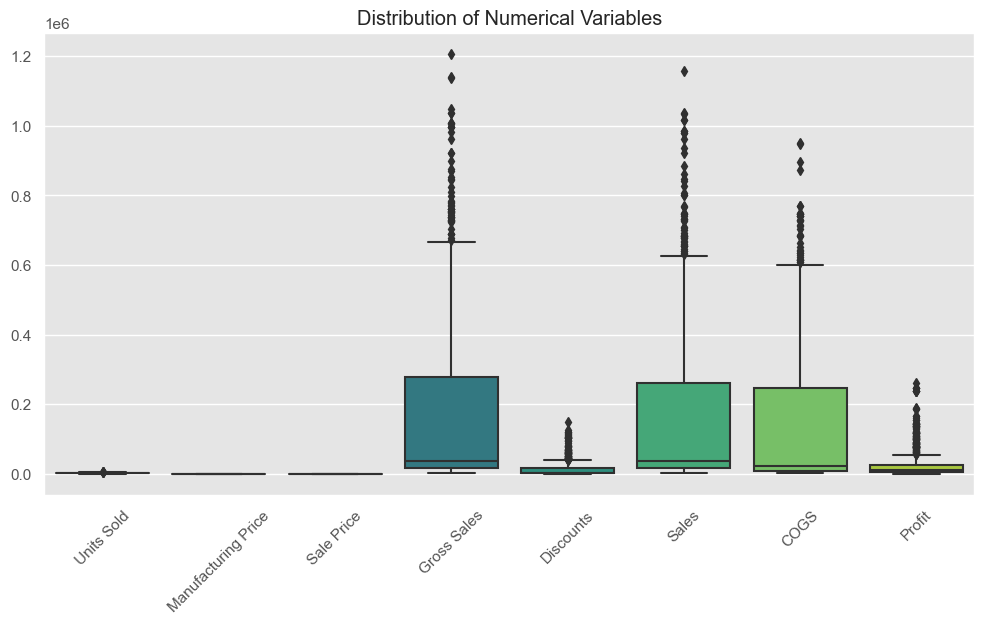

In [176]:
# Create a boxplot to show the distribution of each numerical variable
plt.figure(figsize=(12, 6))
sns.boxplot(data=num_col, palette='viridis')
plt.title('Distribution of Numerical Variables')
plt.xticks(rotation=45)
plt.show()

In [177]:
# handling outliers using median
# Calculate the median of each numerical variable
medians = num_col.median()

# Replace outliers with the median of each variable
for column in num_col.columns:
    q1 = num_col[column].quantile(0.25)
    q3 = num_col[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr # Any value below the lower bound is outlier, above the upperbound-outlier too.
    upper_bound = q3 + 1.5 * iqr
    num_col[column] = num_col[column].apply(lambda x: medians[column] if x < lower_bound or x > upper_bound else x)


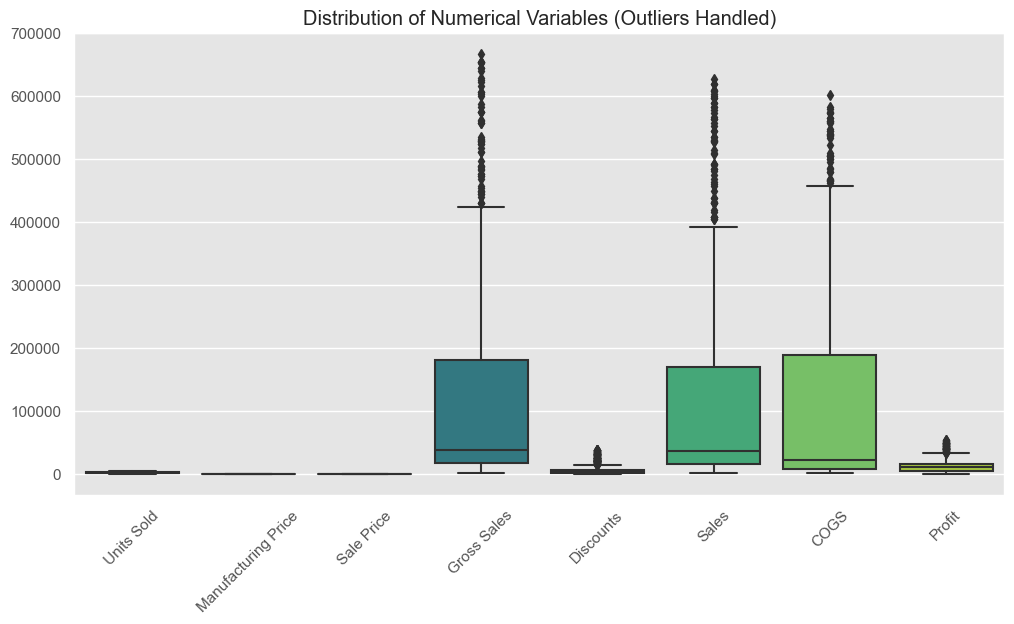

In [178]:
# Create a boxplot to show the distribution of each numerical variable after handling outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=num_col, palette='viridis')
plt.title('Distribution of Numerical Variables (Outliers Handled)')
plt.xticks(rotation=45)
plt.show()

In [179]:
# Concatenating cat_col and num_col

joined_df = pd.concat([num_col, cat_col], axis=1)

In [180]:
joined_df

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Segment,Country,Product,Discount Band,Month Name
0,1618.5,3.0,20.0,32370.0,276.15,32370.00,16185.00,16185.00,Government,Canada,Carretera,None,January
1,1321.0,3.0,20.0,26420.0,276.15,26420.00,13210.00,13210.00,Government,Germany,Carretera,None,January
2,2178.0,3.0,15.0,32670.0,276.15,32670.00,21780.00,10890.00,Midmarket,France,Carretera,None,June
3,888.0,3.0,15.0,13320.0,276.15,13320.00,8880.00,4440.00,Midmarket,Germany,Carretera,None,June
4,2470.0,3.0,15.0,37050.0,276.15,37050.00,24700.00,12350.00,Midmarket,Mexico,Carretera,None,June
...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,2475.0,260.0,300.0,37980.0,2585.25,35540.20,22506.25,12375.00,Small Business,France,Amarilla,High,March
696,546.0,260.0,300.0,163800.0,24570.00,139230.00,136500.00,2730.00,Small Business,Mexico,Amarilla,High,October
697,1368.0,5.0,7.0,9576.0,1436.40,8139.60,6840.00,1299.60,Government,Mexico,Montana,High,February
698,723.0,10.0,7.0,5061.0,759.15,4301.85,3615.00,686.85,Government,Canada,Paseo,High,April


## Exploratory Data Analysis (EDA)

### Univariate Analysis

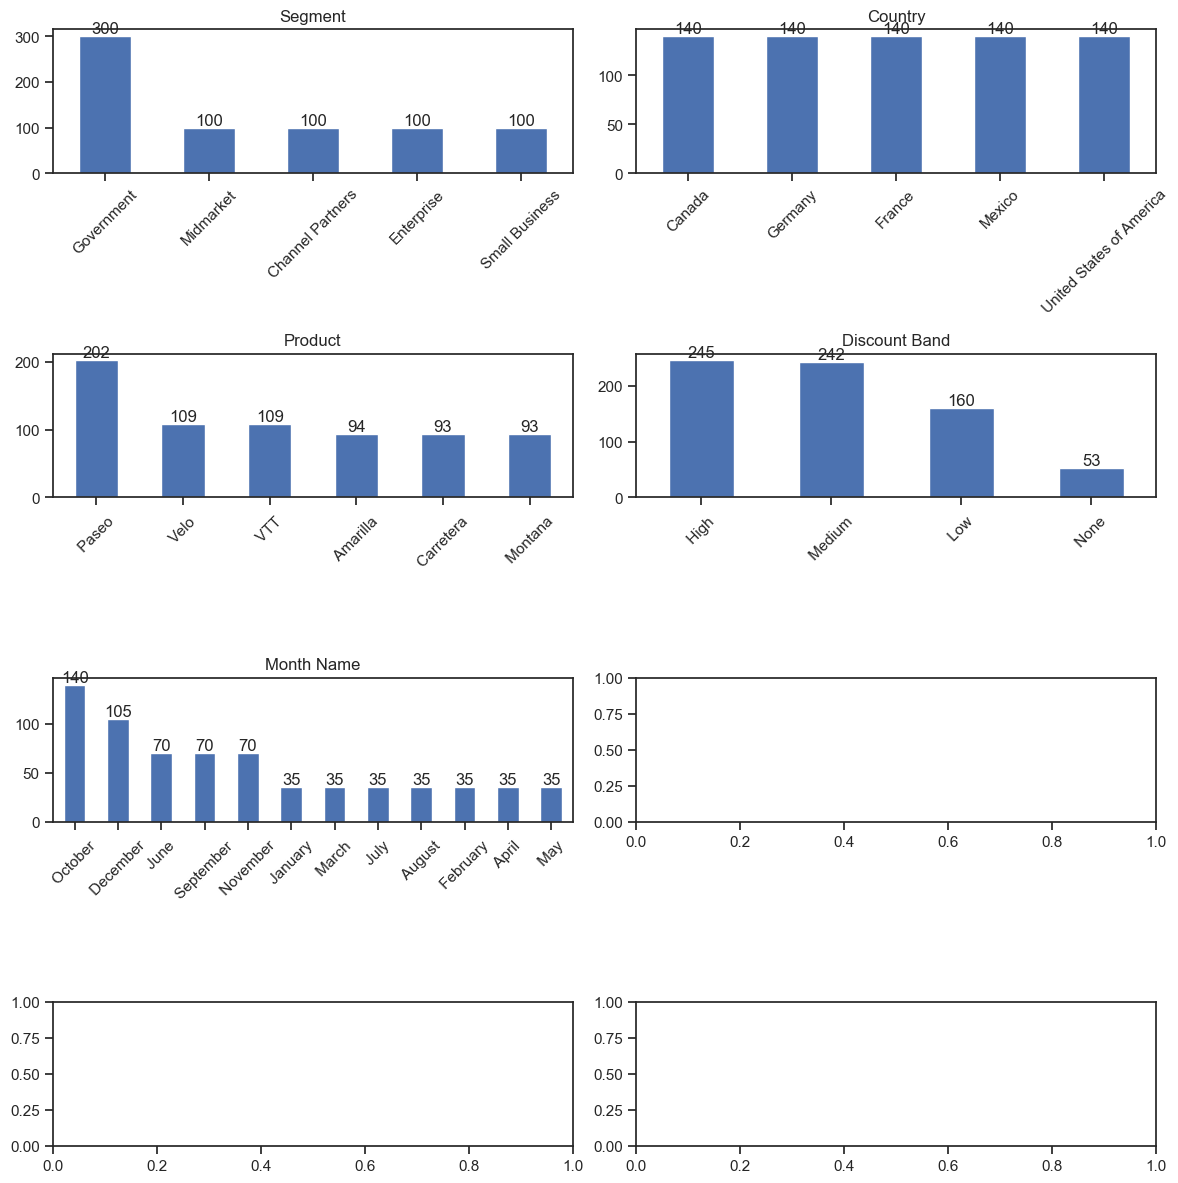

In [216]:
# visualizing the categorical columns
df_cat_vars = joined_df[['Segment', 'Country', 'Product', 'Discount Band', 'Month Name']]

# Create a figure and subplots
fig, axes = plt.subplots(4, 2, figsize=(12, 12))

# Iterate through the columns and plot the charts
for i, col in enumerate(df_cat_vars):
    row = i // 2  # Determine the row index
    col_index = i % 2   # Determine the column index using a different variable name

    # Plot a bar chart for categorical columns
    if col in df_cat_vars:
        counts = joined_df[col].value_counts()
        counts.plot(kind='bar', ax=axes[row, col_index])
        axes[row, col_index].set_title(col)
        axes[row, col_index].set_xlabel('')
        
        # Add data labels
        for index, value in enumerate(counts):
            axes[row, col_index].text(index, value, str(value), ha='center', va='bottom')

        # Rotate x-axis labels
        axes[row, col_index].tick_params(axis='x', rotation=45)

    # Plot a pie chart for Loan_Status column
    else:
        counts = joined_df[col].value_counts()
        counts.plot(kind='pie', ax=axes[row, col_index], autopct='%1.1f%%')
        axes[row, col_index].set_title(col)
        axes[row, col_index].set_ylabel('')

# Adjust the layout and spacing
plt.tight_layout()

# Show the plot
plt.show()

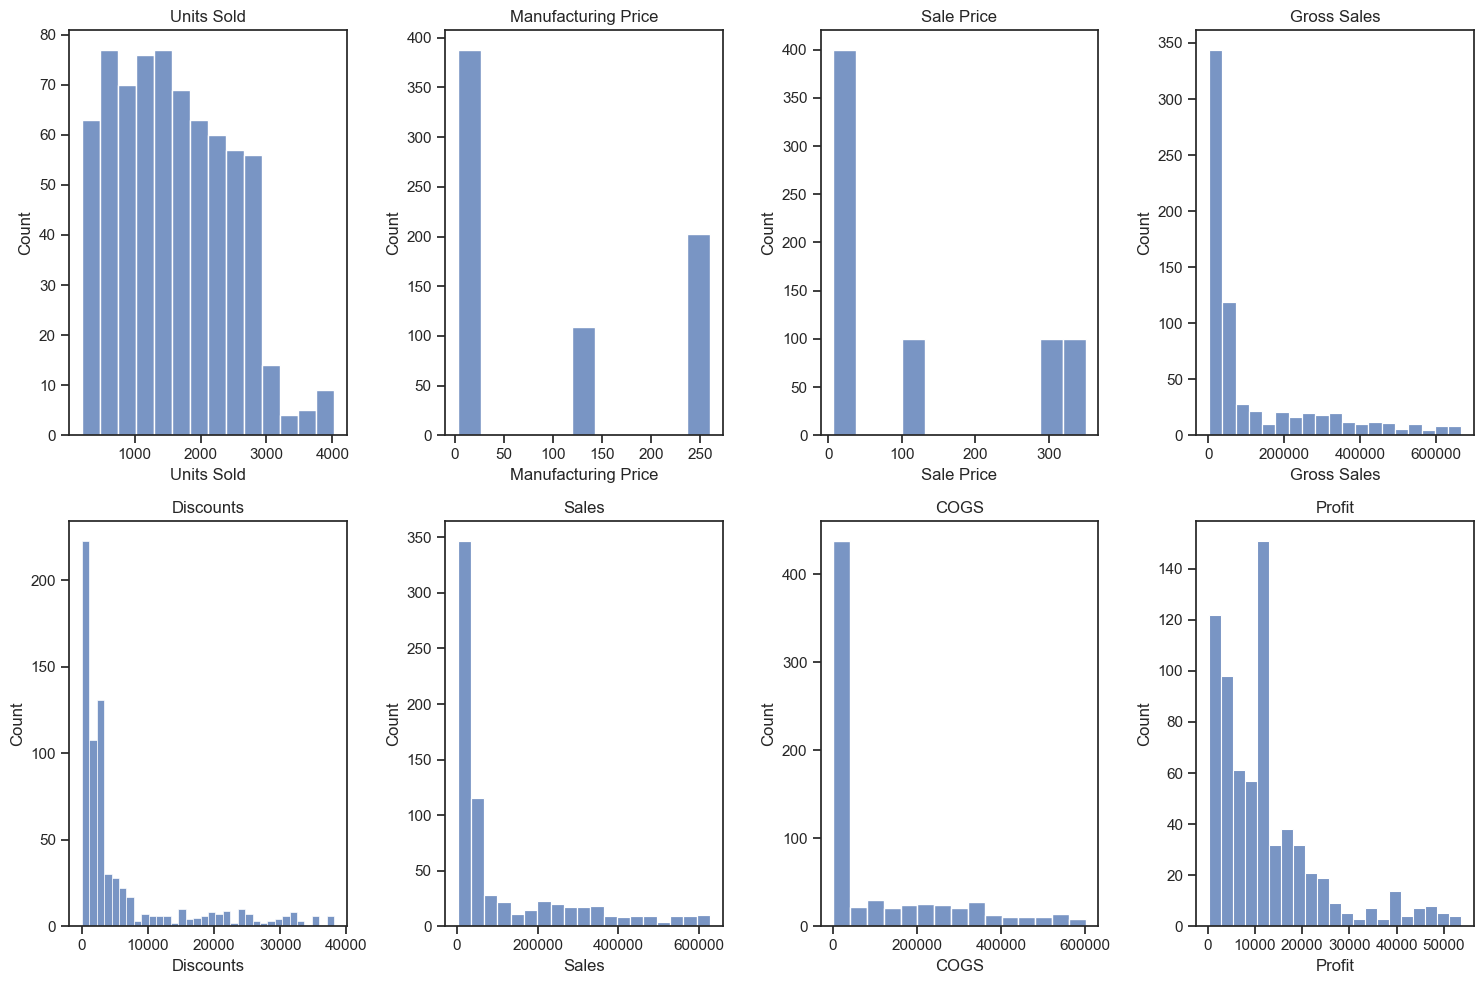

In [217]:
# visualizing Num Columns

# List of columns to visualize
columns = ['Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit']

# Create a figure with subplots
fig, axes = plt.subplots(nrows=int(len(columns) / 4), ncols=4, figsize=(15, 10))

# Iterate through the columns and create subplots
for i, col in enumerate(columns):
    row, col_idx = i // 4, i % 4
    sns.histplot(data=joined_df, x=col, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f"{col}")

plt.tight_layout()
plt.show()

***Based on the bar chart visualization, there are five segments: Government, MidMarket, Channel Partners, Enterprise, and Small Business. The unique value counts for MidMarket, Channel Partners, Enterprise, and Small Business are each 100. The Government segment, with a unique value count of 300, has the highest count among all segments***.

## Bivariate Analysis

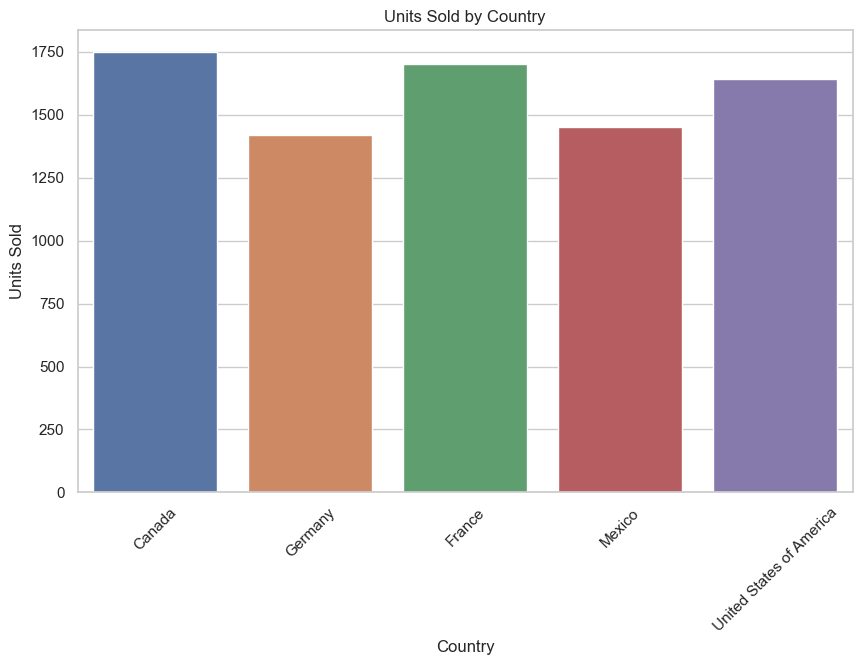

In [218]:
# Country vs Units Sold

# Set the style for the plots
sns.set(style="whitegrid")

# Create a bar plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Country', y='Units Sold', data=joined_df, errorbar=None)

# Add labels and title
plt.xlabel('Country')
plt.ylabel('Units Sold')
plt.title('Units Sold by Country')

# Rotate the x-axis labels if necessary for readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

***The bar chart illustrates the total units sold for each country. Canada recorded the highest sales at 1,750 units, followed by the United States at 1,650 units. France and Mexico reported sales of 1,700+ and 1,480 units, respectively, while Germany sold around 1,450+ units. Based on this analysis, increasing supply to Canada appears to be a strategic move to capitalize on the strong demand.***


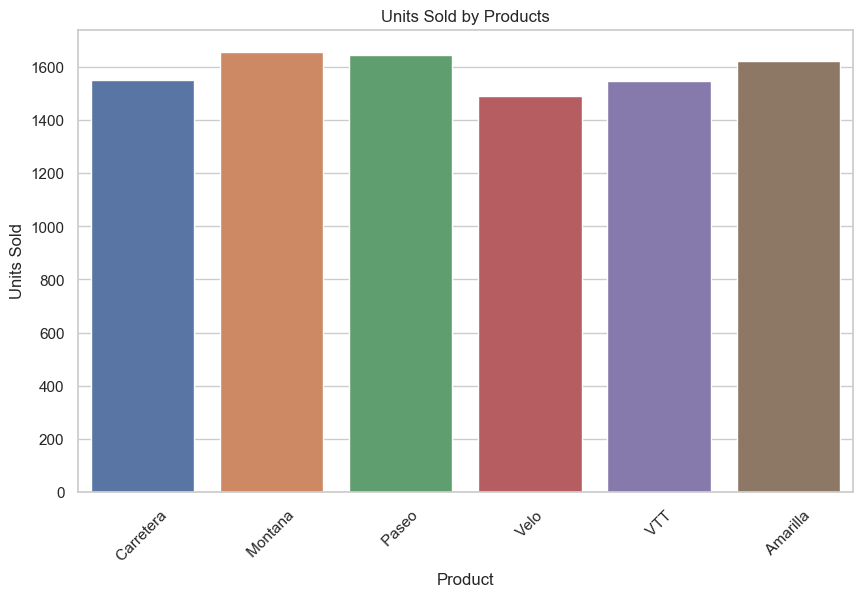

In [219]:
# products vs units sold

# Set the style for the plots
sns.set(style = None)

# Create a bar plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Product', y ='Units Sold', data=joined_df, errorbar=None)

# Add labels and title
plt.xlabel('Product')
plt.ylabel('Units Sold')
plt.title('Units Sold by Products')

# Rotate the x-axis labels if necessary for readability
plt.xticks(rotation=45)

# Display the plot
plt.show()


***The bar chart illustrates the units sold for each of six products: Carretera, Montana, Passo, Velo, VIT, and Avenue. Based on the chart, Montana emerges as the top-selling product with over 1,600 units sold. The remaining products have sales ranging between 1,200 and 1,500 units***.

**This visualization suggests that Montana is the most popular product among consumers. To capitalize on this success, the company might consider increasing production or implementing targeted marketing campaigns to further boost sales. Additionally, analyzing the factors contributing to Montana's popularity could provide insights for improving the performance of other products in the lineup***

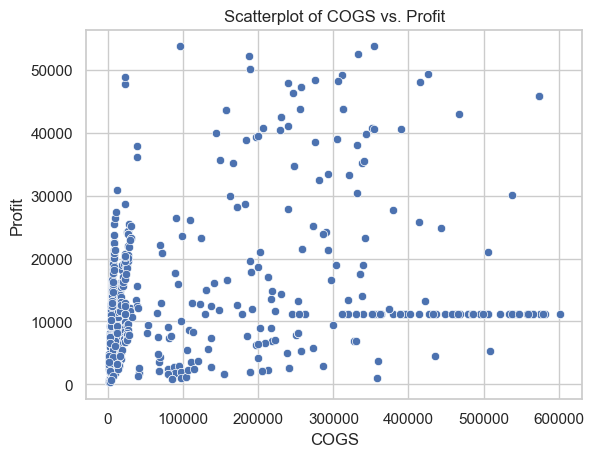

In [185]:
# COGS and profit (scatterplot)
#plot scatterplot
sns.scatterplot(x='COGS', y='Profit', data=joined_df)

plt.title('Scatterplot of COGS vs. Profit')

#add labels to scatterplot
plt.xlabel('COGS')
plt.ylabel('Profit')
plt.show()

***This scatterplot shows the relationship between **COGS (Cost of Goods Sold)** and **Profit**. Each point represents a transaction, with COGS on the horizontal axis and profit on the vertical axis**

- For lower COGS (under 100,000), profits vary a lot, ranging from 0 to 50,000.
- As COGS increases beyond 100,000, profit stays mostly around 10,000, with little increase.

**There doesn’t seem to be a clear positive relationship between COGS and profit. In fact, higher COGS doesn’t lead to higher profits, suggesting a weak or even negative relationship***

In [186]:
# calculating correlation coefficient to verify the type of relationship existing

correlation_coefficient = joined_df['Profit'].corr(joined_df['COGS'])

print("Correlation coefficient:", correlation_coefficient)

Correlation coefficient: 0.34428694048696223


***The correlation coefficient of **0.344** between **COGS (Cost of Goods Sold)** and **Profit** indicates a **weak positive relationship** between the two variables***

- A **positive correlation** means that as COGS increases, profit tends to increase, but only slightly in this case.
- Since the value is closer to 0 than 1, it suggests that the relationship is weak, meaning the changes in COGS are not strongly linked to changes in profit.
  
***In simple terms, while there is a slight tendency for profit to go up as COGS increases, it’s not a strong or consistent pattern. Other factors could be affecting profit more significantly than COGS***.

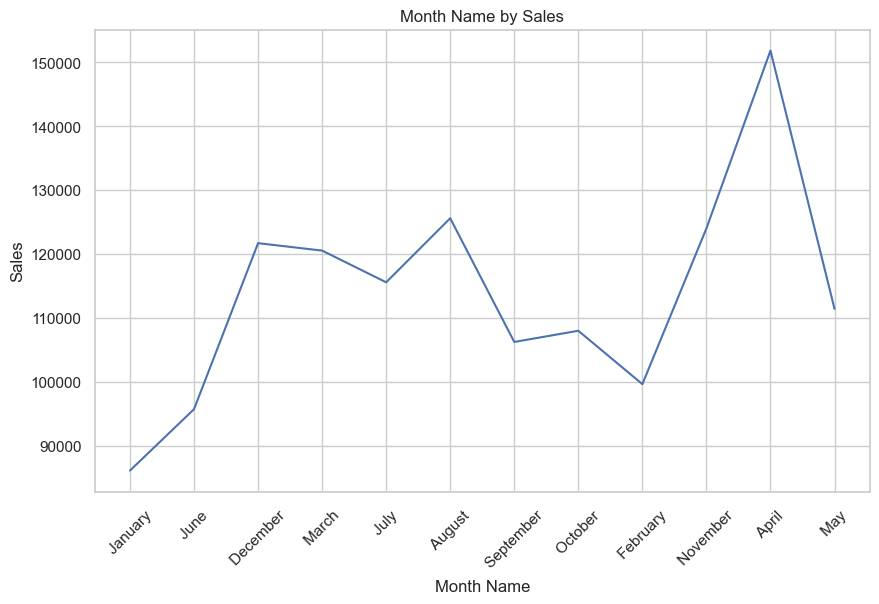

In [187]:
# Month vs Sales

# Set the style for the plots
sns.set(style="whitegrid")

# Create a line plot using Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(x='Month Name', y='Sales', data=joined_df, errorbar=None)

# Add labels and title
plt.xlabel('Month Name')
plt.ylabel('Sales')
plt.title('Month Name by Sales')

# Rotate the x-axis labels if necessary for readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

**The company experienced a steady growth in sales throughout the year, with a significant surge in December. January saw a slight dip in sales, followed by a gradual increase until April. The summer months witnessed a decline in sales, with a slight uptick in September. Overall, the company's sales performance demonstrates a positive trajectory with seasonal patterns, suggesting the effectiveness of marketing strategies and product offerings***.


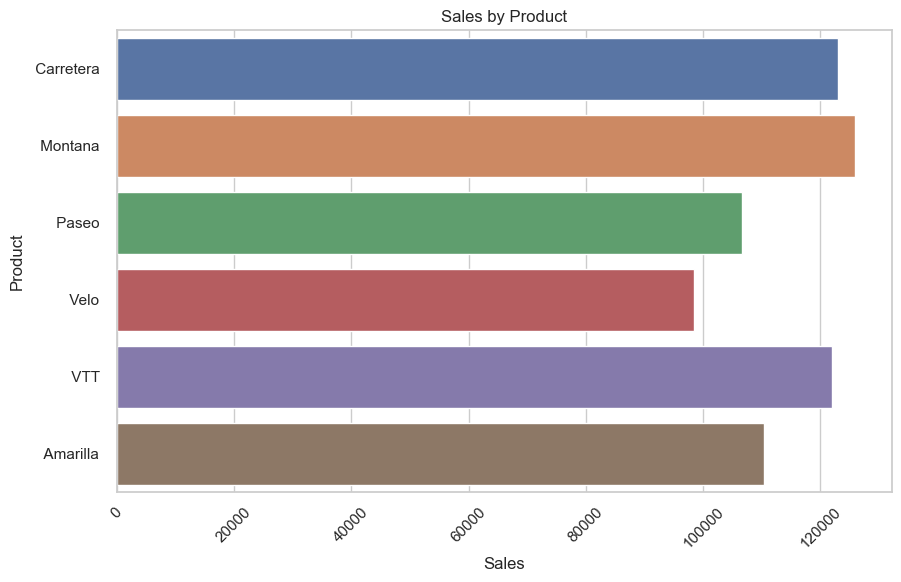

In [188]:
# Product vs Sales

# Set the style for the plots
sns.set(style="whitegrid")

# Create a line plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Sales', y='Product', data=joined_df, errorbar=None)

# Add labels and title
plt.xlabel('Sales')
plt.ylabel('Product')
plt.title('Sales by Product')

# Rotate the x-axis labels if necessary for readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

***The bar chart illustrates the sales performance of six products: Carretera, Montana, Passo, Velo, VIT, and Avenue. Based on the chart, Montana emerges as the top-selling product, followed by Carretera and Passo. VIT and Avenue have relatively lower sales compared to the other products***.

***The company's product lineup showcases a diverse range of offerings, with Montana leading the way in terms of sales. To capitalize on this success, the company might consider expanding the availability of Montana or introducing complementary products to further drive sales. Analyzing the factors contributing to Montana's popularity could provide valuable insights for improving the performance of other products in the lineup***.


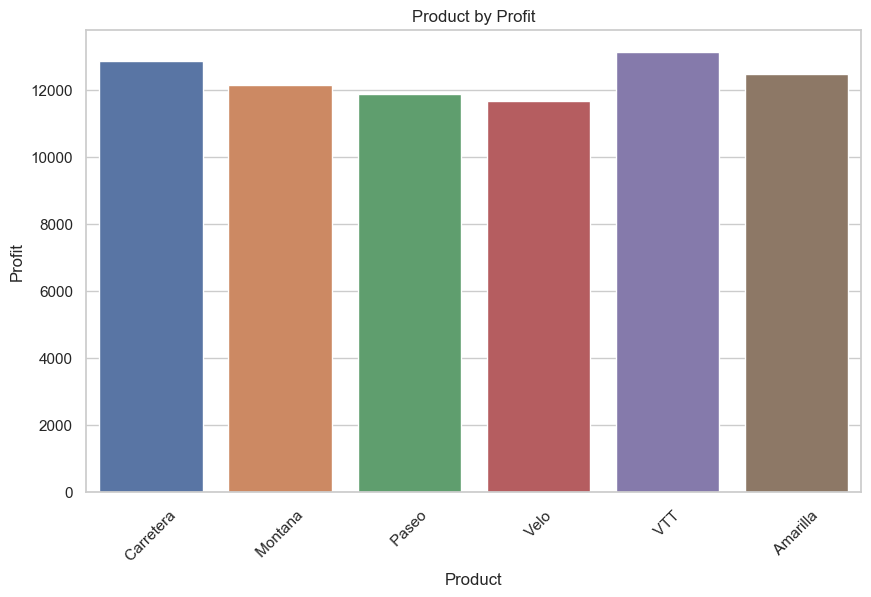

In [189]:
# Product vs Profit

# Set the style for the plots
sns.set(style="whitegrid")

# Create a line plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Product', y='Profit', data=joined_df, errorbar=None)

# Add labels and title
plt.xlabel('Product')
plt.ylabel('Profit')
plt.title('Product by Profit')

# Rotate the x-axis labels if necessary for readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

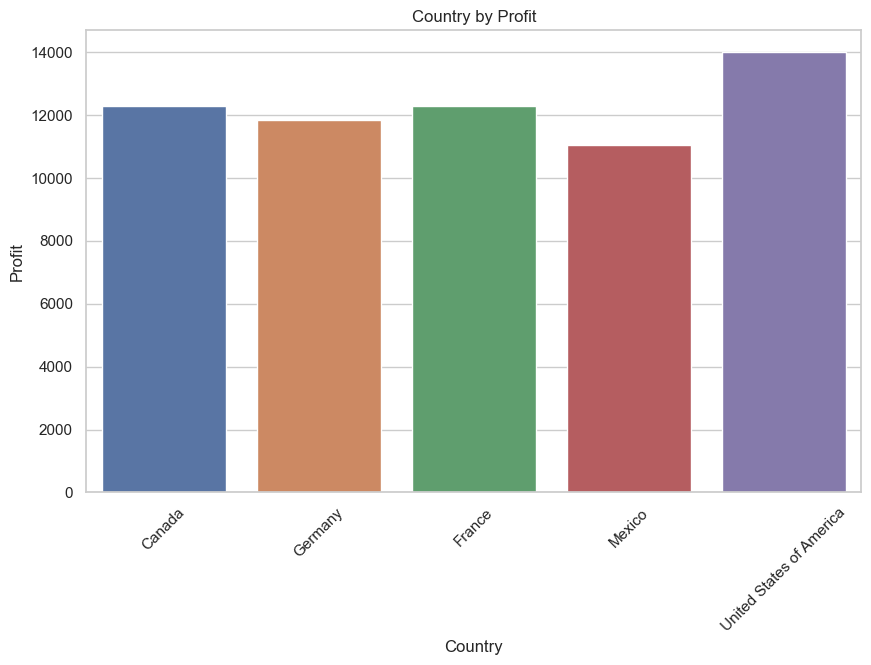

In [190]:
# Country vs Profit

# Set the style for the plots
sns.set(style="whitegrid")

# Create a line plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Country', y='Profit', data=joined_df, errorbar=None)

# Add labels and title
plt.xlabel('Country')
plt.ylabel('Profit')
plt.title('Country by Profit')

# Rotate the x-axis labels if necessary for readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

***The company's operations in the United States appear to be highly successful, generating the highest profit. To capitalize on this success, the company might consider expanding its presence in the United States or implementing similar strategies in other markets with high potential. Analyzing the factors contributing to the United States' profitability could provide valuable insights for improving performance in other regions***

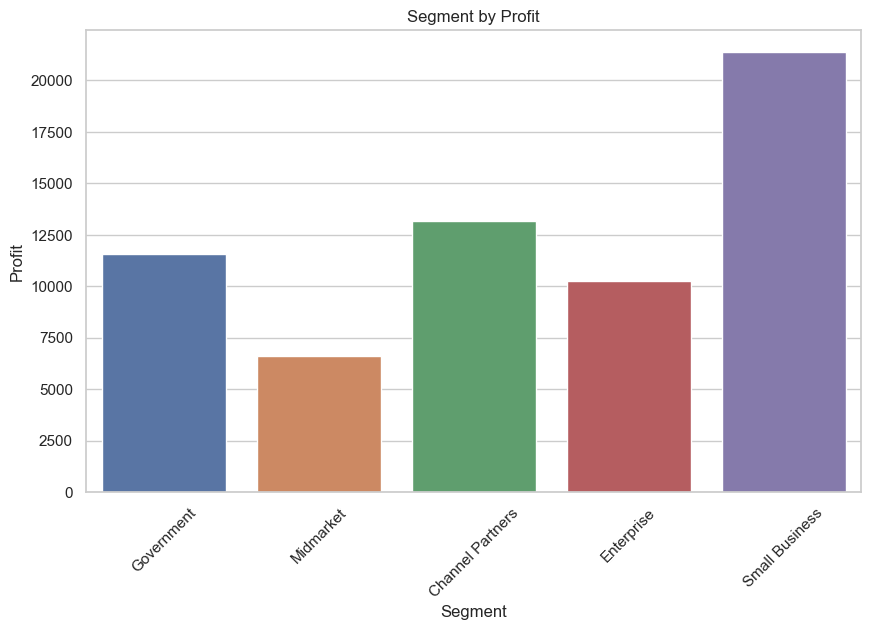

In [191]:
# Segment vs Profit

# Set the style for the plots
sns.set(style="whitegrid")

# Create a line plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='Profit', data=joined_df, errorbar=None)

# Add labels and title
plt.xlabel('Segment')
plt.ylabel('Profit')
plt.title('Segment by Profit')

# Rotate the x-axis labels if necessary for readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

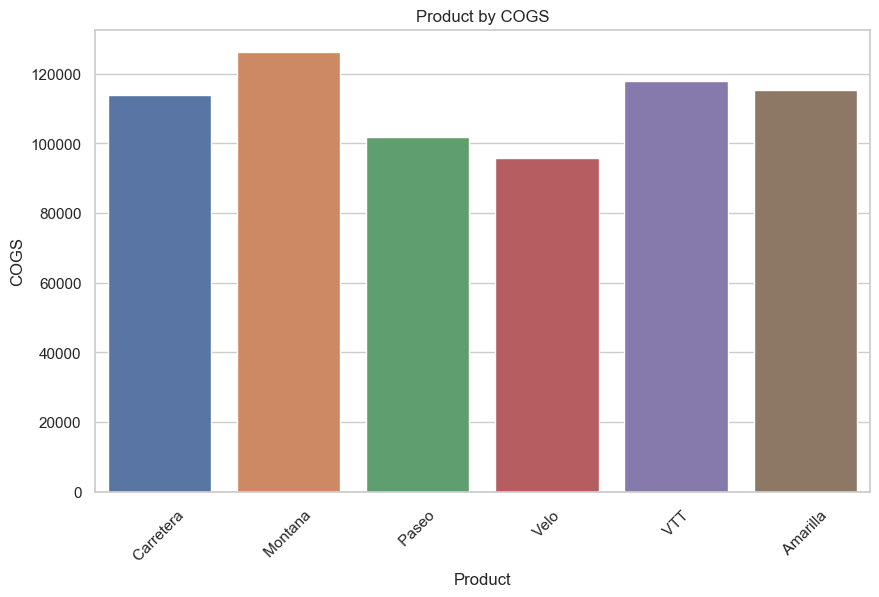

In [192]:
# Product vs COGS

# Set the style for the plots
sns.set(style="whitegrid")

# Create a line plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Product', y='COGS', data=joined_df, errorbar=None)

# Add labels and title
plt.xlabel('Product')
plt.ylabel('COGS')
plt.title('Product by COGS')

# Rotate the x-axis labels if necessary for readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

## Multivariate Analysis

In [194]:
joined_df

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Segment,Country,Product,Discount Band,Month Name
0,1618.5,3.0,20.0,32370.0,276.15,32370.00,16185.00,16185.00,Government,Canada,Carretera,None,January
1,1321.0,3.0,20.0,26420.0,276.15,26420.00,13210.00,13210.00,Government,Germany,Carretera,None,January
2,2178.0,3.0,15.0,32670.0,276.15,32670.00,21780.00,10890.00,Midmarket,France,Carretera,None,June
3,888.0,3.0,15.0,13320.0,276.15,13320.00,8880.00,4440.00,Midmarket,Germany,Carretera,None,June
4,2470.0,3.0,15.0,37050.0,276.15,37050.00,24700.00,12350.00,Midmarket,Mexico,Carretera,None,June
...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,2475.0,260.0,300.0,37980.0,2585.25,35540.20,22506.25,12375.00,Small Business,France,Amarilla,High,March
696,546.0,260.0,300.0,163800.0,24570.00,139230.00,136500.00,2730.00,Small Business,Mexico,Amarilla,High,October
697,1368.0,5.0,7.0,9576.0,1436.40,8139.60,6840.00,1299.60,Government,Mexico,Montana,High,February
698,723.0,10.0,7.0,5061.0,759.15,4301.85,3615.00,686.85,Government,Canada,Paseo,High,April


In [196]:
num_col

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit
0,1618.5,3.0,20.0,32370.0,276.15,32370.00,16185.00,16185.00
1,1321.0,3.0,20.0,26420.0,276.15,26420.00,13210.00,13210.00
2,2178.0,3.0,15.0,32670.0,276.15,32670.00,21780.00,10890.00
3,888.0,3.0,15.0,13320.0,276.15,13320.00,8880.00,4440.00
4,2470.0,3.0,15.0,37050.0,276.15,37050.00,24700.00,12350.00
...,...,...,...,...,...,...,...,...
695,2475.0,260.0,300.0,37980.0,2585.25,35540.20,22506.25,12375.00
696,546.0,260.0,300.0,163800.0,24570.00,139230.00,136500.00,2730.00
697,1368.0,5.0,7.0,9576.0,1436.40,8139.60,6840.00,1299.60
698,723.0,10.0,7.0,5061.0,759.15,4301.85,3615.00,686.85


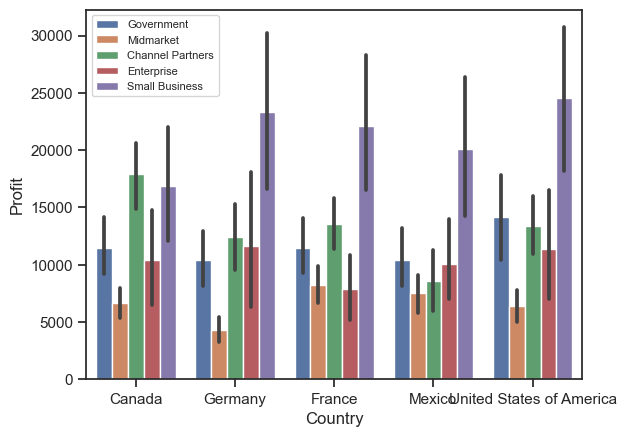

<Figure size 2500x1000 with 0 Axes>

In [215]:
sns.barplot(x='Country', y='Profit', hue='Segment', data=joined_df)


# Move the legend to the top right corner
plt.legend(loc='upper left', fontsize =8)

plt.figure(figsize=(25, 10))
plt.show()

C:\Users\benke\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning:

The figure layout has changed to tight



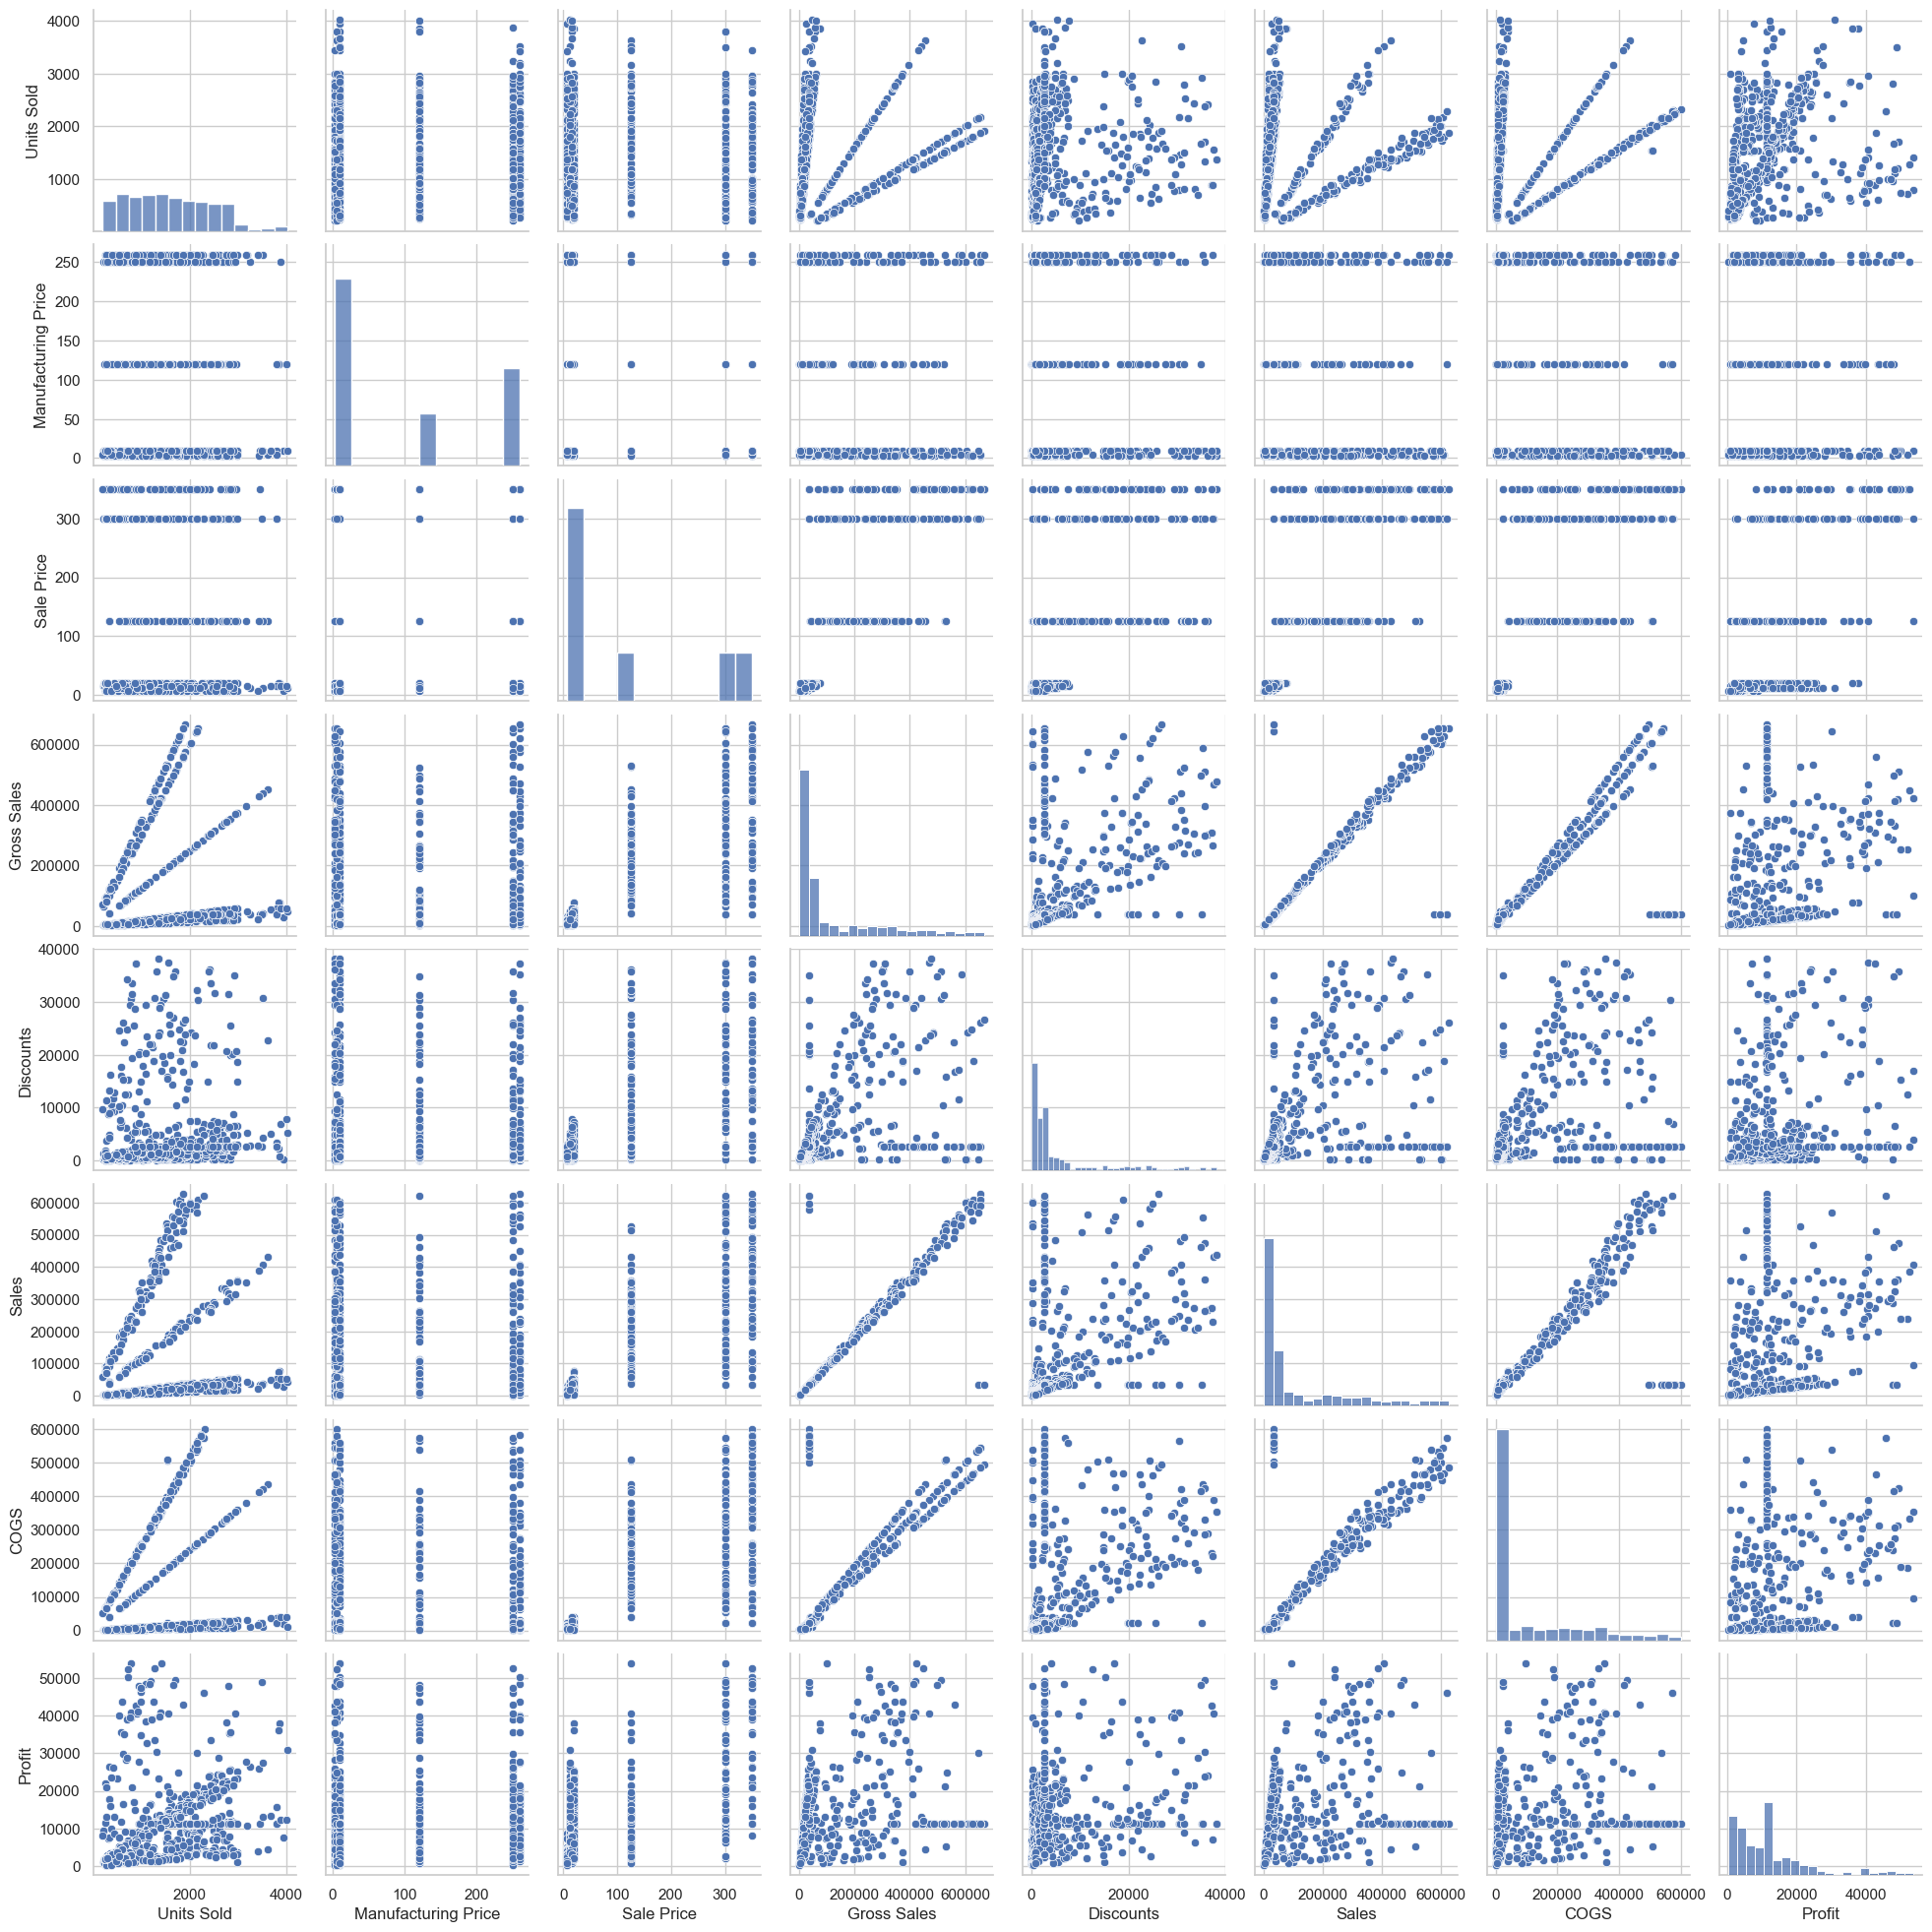

In [197]:
# COGS, Profit, Product
# Select the numerical variables
num_col = joined_df[['Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit']]

# Create a scatterplot matrix using Seaborn
sns.pairplot(num_col)

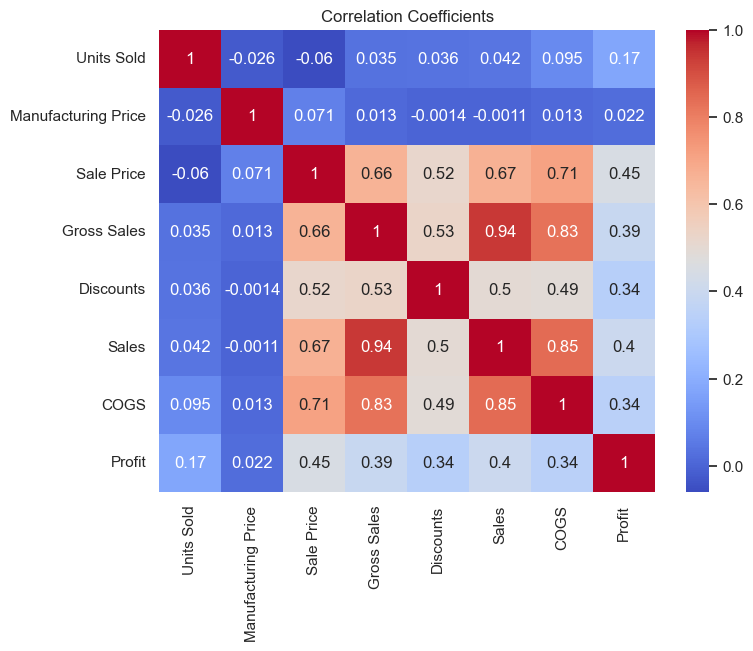

In [198]:
# Calculate the correlation coefficients
correlation_matrix = num_col.corr()

# Display the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Coefficients')
plt.show()